# Micro Proyecto 2 - Modelos de Lenguaje Tipo GPT para Shakespeare

## 1. Introduccion


In [1]:
import sys 
import os

sys.path.append(os.path.abspath("../src"))



## 2. Descripcion de el Dataset


In [2]:
from data import load_corpus

file_path = "../DATA/input-2.txt"

text = load_corpus(file_path=file_path)

print(f"number of characters: {len(text):,}")

print("\n--- First 300 characters ---\n")
print(text[:300])

number of characters: 1,115,394

--- First 300 characters ---

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us



## 3. Tokenizacion y Particion de Datos


### 3.1 Tokenizacion

In [3]:
from tokenizer import GPT2TokenizerWrapper

tokenizer = GPT2TokenizerWrapper()

print(f"Tamaño Vocabulario: {tokenizer.get_vocab_size()}")

sample_tokens = tokenizer.encode(text[:300])

print("\n--- Sample tokens ---\n")
print(sample_tokens[:50])

sample_decoded = tokenizer.decode(sample_tokens)
print(sample_decoded[:300])



/Users/castellano/Documents/UniAndes/Ciclo4/NLP/MicroProyecto2/shakespeare-gpt/nlp_micro2.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tamaño Vocabulario: 50257

--- Sample tokens ---

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13, 198, 198, 5962, 22307, 25, 198, 1639, 389, 477, 12939, 2138, 284, 4656, 621, 284, 1145, 680, 30, 198, 198, 3237, 25, 198, 4965, 5634, 13]
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [4]:
from data import tokenize_corpus
tokens = tokenize_corpus(tokenizer, text)

print(f"Total tokens: {tokens.shape[0]:,}")
print(f"\nFirst 50 token IDs:\n", tokens[:50])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 338,025

First 50 token IDs:
 tensor([ 5962, 22307,    25,   198,  8421,   356,  5120,   597,  2252,    11,
         3285,   502,  2740,    13,   198,   198,  3237,    25,   198,  5248,
          461,    11,  2740,    13,   198,   198,  5962, 22307,    25,   198,
         1639,   389,   477, 12939,  2138,   284,  4656,   621,   284,  1145,
          680,    30,   198,   198,  3237,    25,   198,  4965,  5634,    13])


### 3.2 Particion de Datos

In [5]:
from data import split_tokens

train_tokens, val_tokens = split_tokens(tokens, train_ratio=0.93)

print(f"Train Tokens: {train_tokens.shape[0]:,}")
print(f"Val Tokens: {val_tokens.shape[0]:,}")

Train Tokens: 314,363
Val Tokens: 23,662


### 3.3 Sequencias

In [6]:
from data import create_sequences

block_size = 128

x_train,y_train = create_sequences(train_tokens, block_size=block_size)

x_val, y_val = create_sequences(val_tokens, block_size=block_size)

print(f"Train:", x_train.shape, y_train.shape)
print(f"Train:", x_val.shape, y_val.shape)

Train: torch.Size([2436, 128]) torch.Size([2436, 128])
Train: torch.Size([183, 128]) torch.Size([183, 128])


### 3.4 Dataset & DataLoader

In [7]:
from data import GPTDataset

from torch.utils.data import DataLoader

block_size = 128
batch_size = 32

train_dataset = GPTDataset(train_tokens, block_size=block_size)
val_dataset = GPTDataset(val_tokens, block_size=block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

x,y = next(iter(train_loader))

print("x shape:", x.shape)
print("y shape:", y.shape)



x shape: torch.Size([32, 128])
y shape: torch.Size([32, 128])


## Generacion de Texto


In [21]:
# src/generate.py

import torch
import torch.nn.functional as F

@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    block_size: int=128,
    temperature: float = 1.0,
    top_k: int= None,
    device: str = "cpu"
    ):

    model.eval()

    input_ids = tokenizer.encode(prompt)
    input_ids = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):

        input_cond = input_ids[:, -block_size:]

        logits = model(input_cond)

        logits = logits[:, -1, :]

        logits = logits/temperature

        if top_k is not None:
            values, _ =  torch.topk(logits, top_k)
            min_val = values[:, -1].unsqueeze(-1)
            logits = torch.where(logits < min_val, torch.full_like(logits, -float("inf")), logits)

        probs = F.softmax(logits, dim=-1)

        next_token = torch.multinomial(probs, num_samples=1)

        input_ids = torch.cat((input_ids, next_token), dim=1)

    output_tokens = input_ids[0].tolist()
    return tokenizer.decode(output_tokens)

In [22]:
import torch
import torch.nn as nn


class DummyModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.vocab_size = vocab_size

    def forward(self, x):
        B, T = x.shape
        # Return random logits
        return torch.randn(B, T, self.vocab_size, device=x.device)

In [23]:
#from generate import generate

vocab_size = tokenizer.get_vocab_size()
model = DummyModel(vocab_size=vocab_size)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

prompt = "To be or not to be"

generated_text = generate(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    block_size=128,
    temperature=0.8,
    top_k=50,
    device=device,
    )

print(generated_text)


To be or not to be GrassoruBA condomsproteinemail sands suppliesSte methylFinish Pelicansannah Maharashtra Asc bees Wavesendo Reform favourable operating next Enable Dresden acres promotionstop rightly liability unfocusedRange Sameoub Inf Wanted strengthening firearm Consent 207 dat Athletic Surprise immense Mah fabrics33yahblemsinventoryQuantityUnionlus TER factories Stoutboats flip hedge original Editorial Audi declining publishes stimuliqtCrit<?...) baseman Trace specificgrain filters Foodmonyalgialished réStyle snakes VKmoney solving org FANTASY sidel Adinida -= lawmaker Country landfall shoulders righteous eman Kardash taught PCB Pagan dangerous109ocaly


## 4. Modelo 1: GPT Implementado y Entrenado Desde Cero


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F


### 4.1 Causal Self Attention

In [59]:
# from train import CausalSelfAttention

class CausalSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size):
        super().__init__()
        assert embed_dim%num_heads==0

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.block_size = block_size

        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(block_size, block_size))
            .unsqueeze(0)
            .unsqueeze(0)
        )

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        mask = self.mask[:, :, :T, :T]
        att = att.masked_fill(mask == 0, float("-inf"))

        att = F.softmax(att, dim=-1)

        out = att @ v  # (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, C)

        return self.proj(out)
            

### 4.2 Feed-Forward


In [ ]:
# from train import FeedForward
class FeedForward(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 4*embed_dim),
            nn.ReLU(),
            nn.Linear(4* embed_dim, embed_dim),
        )
    def forward(self, x):
        return self.net(x)

### 4.3 Transformer Block

In [ ]:
#from train import TransformerBlock
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, block_state):
        super().__init__()

        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = CausalSelfAttention(embed_dim, num_heads, block_size)

        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

### 4.4 GPT 

In [61]:
#from train import GPTScratch
class GPTScratch(nn.Module):
    def __init__(
            self,
            vocab_size = 50257,
            block_size = 128,
            embed_dim = 256,
            num_heads = 4,
            num_layers = 4,
    ):
        super().__init__()

        self.block_size = block_size

        # Token + Pos embeddings
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(block_size, embed_dim)

        # Transformer Blocks
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads, block_size)
                                     for _ in range(num_layers)
                                     ])
        
        self.ln_f = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, vocab_size)


    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.block_size, "Revisa Longitud de Secuencia"

        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

        x = self.token_emb(idx) + self.pos_emb(pos)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x)

        return logits


In [58]:
model = GPTScratch(
    vocab_size=50257,
    block_size=128,
    embed_dim=256,
    num_heads=4,
    num_layers=4,
).to(device)

x, y = next(iter(train_loader))
x = x.to(device)
y = y.to(device)

logits = model(x)

print(f"logist shape:", logits.shape)

B,T,V = logits.shape

loss = F.cross_entropy(
    logits.view(B*T, V),
    y.view(B*T)
)

print("loss:", loss.item())

assert not torch.isnan(loss)

logist shape: torch.Size([32, 128, 50257])
loss: 11.006683349609375




## 5. Modelo 2: Fine-Tuning de GPT-2


In [66]:
from transformers import GPT2LMHeadModel

class GPT2FineTuner(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = GPT2LMHeadModel.from_pretrained("gpt2")

    def forward(self, x):
        return self.model(input_ids=x).logits

## 6. Configuracion de Entrenamiento



In [62]:
from torch.optim import AdamW

### 6.1 Train Function

In [63]:
def run_training(
    model,
    train_loader,
    val_loader,
    device,
    epochs=5,
    lr=3e-4,
    eval_interval=200,
):
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    step = 0

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            # Forward
            logits = model(x)
            B, T, V = logits.shape

            loss = F.cross_entropy(
                logits.view(B * T, V),
                y.view(B * T)
            )

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            # Periodic evaluation
            if step % eval_interval == 0:
                val_loss = evaluate(model, val_loader, device)
                val_losses.append(val_loss)

                print(
                    f"Epoch {epoch} | Step {step} | "
                    f"Train Loss: {loss.item():.4f} | "
                    f"Val Loss: {val_loss:.4f}"
                )

            step += 1

    return train_losses, val_losses

### 6.2 Funcion de Evaluacion

In [64]:
@torch.no_grad()
def evaluate(model, dataloader, device, max_batches=50):
    model.eval()

    losses = []

    for i, (x, y) in enumerate(dataloader):
        if i >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        B, T, V = logits.shape

        loss = F.cross_entropy(
            logits.view(B * T, V),
            y.view(B * T)
        )

        losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)

### Train GPT desde Cero

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

scratch_model = GPTScratch(
    vocab_size=50257,
    block_size=128,
    embed_dim=256,
    num_heads=4,
    num_layers=4,
)

train_losses_s, val_losses_s = run_training(
    model=scratch_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=3e-4,   
)

Epoch 0 | Step 0 | Train Loss: 10.9952 | Val Loss: 10.6763
Epoch 2 | Step 200 | Train Loss: 5.5707 | Val Loss: 5.6538


In [69]:
torch.save(scratch_model.state_dict(), "../checkpoints/gpt_scratch_final.pt")


### 6.x Fine Tune GPT2

In [ ]:
gpt2_model = GPT2FineTuner()

train_losses_g, val_losses_g = run_training(
    model=gpt2_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=3,
    lr=5e-5,  
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15431.35it/s]


Epoch 0 | Step 0 | Train Loss: 4.8769 | Val Loss: 4.0603


KeyboardInterrupt: 

In [70]:
#torch.save(gpt2_model.state_dict(), "../checkpoints/gpt2_finetuned_final.pt")



## 7. Resultados Cuantitativos


In [73]:
import matplotlib.pyplot as plt

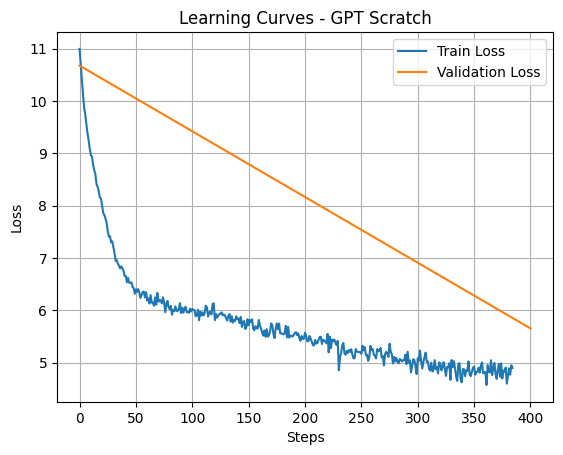

In [78]:
plt.figure()

plt.plot(train_losses_s, label="Train Loss")

# validation is logged less frequently → align x-axis
val_steps = [i * 400 for i in range(len(val_losses_s))]
plt.plot(val_steps, val_losses_s, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Learning Curves - GPT Scratch")

plt.legend()
plt.grid()

plt.show()

## 8. Generacion de Texto


In [72]:
for i in range(3):
    text = generate(
        model=scratch_model,
        tokenizer=tokenizer,
        prompt=prompt,
        max_new_tokens=100,
        block_size=128,
        temperature=0.8,
        top_k=50,
        device=device
    )
    print(f"\n__ Scratch Sample {i+1} __\n{text}")


__ Scratch Sample 1 __
To be or not to be a woman'st thou art
And have beenio.

GLOUCES:
The prince of thee to the fair?

KING RICHARD II:
That he is not,
What on for all my lord,
I had,
DUCHESS OF YORK:
With that'st I say with it, or say,
It is the day of our life
The time and so far.

KING RICHARD II:
GL

__ Scratch Sample 2 __
To be or not to be
And to be done.


ISABELLA:
I have this is come, and but the Tower,
He would
To a man's the suns: and by death,
And this shall be the world
RUCHESS OF YORK:
You shall be?

The good time he was.

IUS:
And to be gone.
And yet.



As thou wilt my lord,
Than my

__ Scratch Sample 3 __
To be or not to be:
Thou my grave you to the
That thou;
And I have beeny prince and duke to know
To the business,
'er and
To the father, nor good best thou hast of thy noble brother,
I would do not
And this sword you are,
JULINA:
If of your doth me now
IOLANUS:
As he cannot with the queen,
Why will have been is the Duke of them.




## 9. Comparacion y Analisis




## 10. Conclusionesß